# SHAP空間による農業レジーム拡張分析

**対象年：2020年**。保存済みOOF予測・SHAPも2020年の成果物だけを使う。
実行環境：サーバー（`/work/tsuda`）。
Interaction dependence plotでは、`viridis`の紫が第2変数の低値、黄色が高値を表す。

元Notebook `cropland_soil_group_wetland_excluded_oof_shap.ipynb` の保存済み成果物を優先して再利用する。

実行内容：

1. 標準Tree SHAP interaction values
2. 統合Shapleyベクトルのクラスタリング
3. PCA / UMAPによるexplanation embedding
4. クラスタの世界地図とレジームプロファイル
5. クラスタ別二段階LightGBMと保存済みOOFとの性能比較
6. 主要interaction dependence plot

既存のOOF予測・統合Shapleyは再計算しない。モデル自体を保存していない場合に限り、Interaction SHAPとクラスタ別LightGBMのために必要な範囲だけ再学習する。

## 1. 設定と出力先

サーバー上のパスを使う。GAEZのルートは `/work/tsuda/GAEZ`。
モデル成果物のフォルダ名は元コードに合わせて年 suffix なしとする。

In [1]:
from pathlib import Path
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)

ROOT = Path('/work/tsuda')
GAEZ_DIR = ROOT / 'GAEZ'
TARGET_YEAR = 2020
MODEL_OUTPUT_DIR = GAEZ_DIR / 'CroplandRegression' / 'soil_group_calorie_only_50km'
ARCHIVE_DIR = GAEZ_DIR / 'integrated_shapley_archive_bg32_perm32'
EXT_OUTPUT_DIR = MODEL_OUTPUT_DIR / f'shap_regime_extension_{TARGET_YEAR}'
EXT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_MODEL_NAME = 'soil_group_wetland_excluded'
PREDICTION_COLUMN = f'pred_{FINAL_MODEL_NAME}'
RANDOM_SEED = 42
N_SPLITS = 5
N_CLUSTERS = 4
CLUSTER_MAX_ROWS = 250000
UMAP_MAX_ROWS = 30000
INTERACTION_MAX_ROWS_PER_FOLD = 3000
TOP_INTERACTIONS = 6
RUN_CLUSTER_LGBM = True
REUSE_INTERACTION_CACHE = True

BASE_FEATURES = [
    'elevation_m', 'slope', 'exclusion_class',
    'log_city_time_20k_min', 'log_port_time_any_min',
    'rainfed_calorie_top5_raw',
    'irrigation_calorie_gain_top5_raw',
    'wx_50km_rainfed_calorie_top5_raw',
    'log_distance_river_gt10_2020', 'log_glofas_p10_2020',
]
SOIL_FEATURES = BASE_FEATURES + ['soil_group_class']
CATEGORICAL_CANDIDATES = ['exclusion_class', 'soil_group_class']

FEATURE_LABELS = {
    'elevation_m': 'Elevation',
    'slope': 'Slope',
    'exclusion_class': 'Environmental exclusion class',
    'soil_group_class': 'Soil group',
    'rainfed_calorie_top5_raw': 'Local rainfed calorie potential',
    'irrigation_calorie_gain_top5_raw': 'Potential calorie gain from irrigation',
    'wx_50km_rainfed_calorie_top5_raw': '50-km rainfed calorie potential',
    'log_distance_river_gt10_2020': 'Distance to major river',
    'log_glofas_p10_2020': 'Low-flow river discharge',
    'log_city_time_20k_min': 'Travel time to city',
    'log_port_time_any_min': 'Travel time to port',
}

print('Model output:', MODEL_OUTPUT_DIR)
print('New output:', EXT_OUTPUT_DIR)

Model output: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km
New output: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020


## 2. 保存済みOOF予測・ローカルSHAP・統合Shapleyの読込

元Notebookのセル15・45と同じファイルを使う。クラスタリングは全セルの `shap_feature__...` ベクトルを優先し、統合アーカイブがない場合だけ保存済みローカルSHAPへフォールバックする。

In [2]:
PREDICTIONS_PATH = MODEL_OUTPUT_DIR / 'soil_comparison_oof_predictions.csv.gz'
LOCAL_SHAP_PATH = MODEL_OUTPUT_DIR / 'soil_model_oof_local_feature_shap.csv.gz'
FEATURE_CELL_PATH = ARCHIVE_DIR / 'integrated_feature_shapley_by_cell.csv.gz'
CANONICAL_PATH = ARCHIVE_DIR / 'integrated_shapley_all_cells_canonical.csv.gz'
GROUP_CELL_PATH = ARCHIVE_DIR / 'integrated_group_shapley_by_cell.csv.gz'
METADATA_PATH = ARCHIVE_DIR / 'integrated_shapley_metadata.json'

for required_path in [PREDICTIONS_PATH, LOCAL_SHAP_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

def read_gzip_csv_checked(path):
    try:
        return pd.read_csv(path, compression='gzip')
    except EOFError as error:
        raise RuntimeError(
            f'Gzip file is incomplete or corrupted: {path}. '
            'Regenerate the 2020 OOF artifact before running this notebook.'
        ) from error

oof_predictions = read_gzip_csv_checked(PREDICTIONS_PATH)
local_feature_shap = read_gzip_csv_checked(LOCAL_SHAP_PATH)
print('OOF prediction rows:', f'{len(oof_predictions):,}')
print('Local SHAP rows:', f'{len(local_feature_shap):,}')
print('Prediction columns:', [c for c in oof_predictions.columns if c.startswith('pred_')])

if FEATURE_CELL_PATH.exists():
    feature_cells = pd.read_csv(FEATURE_CELL_PATH, compression='gzip')
    FEATURE_SOURCE = str(FEATURE_CELL_PATH)
elif CANONICAL_PATH.exists():
    canonical_cells = pd.read_csv(CANONICAL_PATH, compression='gzip')
    canonical_shap_cols = [c for c in canonical_cells.columns if c.startswith('shap_feature__')]
    canonical_ids = [c for c in ['fold', 'sample_index', 'row', 'col', 'lat', 'lon', 'spatial_block', 'presence', 'cropland_fraction', 'weight', 'predicted_final_fraction'] if c in canonical_cells.columns]
    feature_cells = canonical_cells[canonical_ids + ['feature_background_baseline'] + canonical_shap_cols].copy()
    FEATURE_SOURCE = str(CANONICAL_PATH)
else:
    fallback = local_feature_shap[local_feature_shap['stage'].eq('conditional_fraction_regressor')].copy()
    fallback = fallback.drop_duplicates(subset=['row', 'col']).reset_index(drop=True)
    fallback = fallback.rename(columns={c: c.replace('shap__', 'shap_feature__') for c in fallback.columns if c.startswith('shap__')})
    feature_cells = fallback
    FEATURE_SOURCE = 'local conditional SHAP fallback'

shap_feature_cols = [c for c in feature_cells.columns if c.startswith('shap_feature__')]
if not shap_feature_cols:
    raise RuntimeError('No shap_feature__ columns were found in the saved results.')

print('Feature-SHAP source:', FEATURE_SOURCE)
print('Feature-SHAP rows:', f'{len(feature_cells):,}')
print('Feature-SHAP columns:', shap_feature_cols)
if GROUP_CELL_PATH.exists():
    group_cells = pd.read_csv(GROUP_CELL_PATH, compression='gzip')
    print('Group-SHAP rows:', f'{len(group_cells):,}')
    print('Group-SHAP columns:', [c for c in group_cells.columns if c.startswith('shap_group__')])
else:
    group_cells = None
    print('Group-SHAP archive not found; feature-SHAP is sufficient for this notebook.')
if METADATA_PATH.exists():
    with open(METADATA_PATH, encoding='utf-8') as file:
        saved_shap_metadata = json.load(file)
    print('Saved Shapley unit:', saved_shap_metadata.get('shapley_unit'))
    saved_target_year = saved_shap_metadata.get('target_year')
    if saved_target_year is not None and int(saved_target_year) != TARGET_YEAR:
        raise RuntimeError(
            f'Saved integrated SHAP metadata is for {saved_target_year}, '
            f'but this notebook is configured for {TARGET_YEAR}.'
        )

if PREDICTION_COLUMN not in oof_predictions.columns:
    raise KeyError(f'Missing saved OOF column: {PREDICTION_COLUMN}')

display(oof_predictions.head(2))
display(feature_cells[[c for c in ['sample_index', 'row', 'col', 'lat', 'lon'] if c in feature_cells.columns] + shap_feature_cols[:3]].head(2))

OOF prediction rows: 240,000
Local SHAP rows: 100,000
Prediction columns: ['pred_no_soil_wetland_excluded', 'pred_soil_group_wetland_excluded']
Feature-SHAP source: /work/tsuda/GAEZ/integrated_shapley_archive_bg32_perm32/integrated_feature_shapley_by_cell.csv.gz
Feature-SHAP rows: 240,000
Feature-SHAP columns: ['shap_feature__elevation_m', 'shap_feature__slope', 'shap_feature__exclusion_class', 'shap_feature__log_city_time_20k_min', 'shap_feature__log_port_time_any_min', 'shap_feature__rainfed_calorie_top5_raw', 'shap_feature__irrigation_calorie_gain_top5_raw', 'shap_feature__wx_50km_rainfed_calorie_top5_raw', 'shap_feature__log_distance_river_gt10_2020', 'shap_feature__log_glofas_p10_2020', 'shap_feature__soil_group_class']
Group-SHAP rows: 240,000
Group-SHAP columns: ['shap_group__land_soil', 'shap_group__climate_water', 'shap_group__market_infrastructure']
Saved Shapley unit: Final cropland-fraction units


,row,col,lat,lon,spatial_block,presence,cropland_fraction,exclusion_class,soil_group_class,pred_no_soil_wetland_excluded,pred_soil_group_wetland_excluded
0,796,2993,23.624954,69.45824,420,1,0.039656,4,26,0.10862,7.119673e-02
1,212,3339,72.291600,98.29156,603,0,0.000000,1,9,0.00000,1.493483e-07


,sample_index,row,col,lat,lon,shap_feature__elevation_m,shap_feature__slope,shap_feature__exclusion_class
0,0,796,2993,23.624954,69.45824,-0.010539,0.015069,-0.023685
1,1,212,3339,72.291600,98.29156,0.004066,0.002079,0.005265


In [3]:
from pathlib import Path
import gzip

def check_gzip_file(path):
    path = Path(path)

    print("File:", path)
    print("Exists:", path.exists())
    print("Size:", f"{path.stat().st_size:,} bytes" if path.exists() else "N/A")

    if not path.exists():
        return False

    try:
        with gzip.open(path, "rb") as f:
            while f.read(1024 * 1024):
                pass
        print("gzip integrity: OK")
        return True

    except (EOFError, gzip.BadGzipFile, OSError) as error:
        print("gzip integrity: BROKEN")
        print(type(error).__name__, error)
        return False


check_gzip_file(PREDICTIONS_PATH)
check_gzip_file(LOCAL_SHAP_PATH)

File: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_comparison_oof_predictions.csv.gz
Exists: True
Size: 6,929,191 bytes
gzip integrity: OK
File: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/soil_model_oof_local_feature_shap.csv.gz
Exists: True
Size: 11,286,441 bytes
gzip integrity: OK


True

## 3. SHAP / 統合Shapleyベクトルのクラスタリング

各セルの説明ベクトルを標準化してMiniBatchKMeansで4つのレジーム候補に分ける。これは気候帯ではなく、モデルが予測を説明した理由の近さによるクラスタリングである。

In [4]:
cluster_cells = feature_cells.copy()
shap_matrix = cluster_cells[shap_feature_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float32)
valid_vector = np.isfinite(shap_matrix).all(axis=1)
cluster_cells = cluster_cells.loc[valid_vector].reset_index(drop=True)
shap_matrix = shap_matrix[valid_vector]

if len(cluster_cells) < N_CLUSTERS:
    raise ValueError('Fewer valid SHAP vectors than requested clusters.')

scaler = StandardScaler()
shap_z = scaler.fit_transform(shap_matrix).astype(np.float32)
cluster_model = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_SEED,
    batch_size=4096,
    n_init=10,
    max_iter=300,
)
cluster_cells['shap_cluster'] = cluster_model.fit_predict(shap_z).astype(np.int16)

silhouette_n = min(10000, len(cluster_cells))
silhouette_rng = np.random.default_rng(RANDOM_SEED + 1)
silhouette_idx = silhouette_rng.choice(len(cluster_cells), silhouette_n, replace=False)
silhouette_labels = cluster_cells['shap_cluster'].to_numpy()[silhouette_idx]
silhouette = silhouette_score(shap_z[silhouette_idx], silhouette_labels) if len(np.unique(silhouette_labels)) > 1 else np.nan
print('Valid vectors:', f'{len(cluster_cells):,}')
print('Silhouette score on diagnostic sample:', round(float(silhouette), 4))

profile_rows = []
for cluster_id, group in cluster_cells.groupby('shap_cluster', sort=True):
    values = group[shap_feature_cols].to_numpy(dtype=float)
    abs_mean = np.nanmean(np.abs(values), axis=0)
    signed_mean = np.nanmean(values, axis=0)
    dominant_idx = int(np.argmax(abs_mean))
    row = {
        'shap_cluster': int(cluster_id),
        'n': int(len(group)),
        'share_percent': 100 * len(group) / len(cluster_cells),
        'dominant_feature': shap_feature_cols[dominant_idx].replace('shap_feature__', ''),
        'dominant_mean_abs_shap': float(abs_mean[dominant_idx]),
        'mean_total_abs_shap': float(np.sum(abs_mean)),
    }
    row.update({'mean_abs__' + c.replace('shap_feature__', ''): float(v) for c, v in zip(shap_feature_cols, abs_mean)})
    row.update({'mean_signed__' + c.replace('shap_feature__', ''): float(v) for c, v in zip(shap_feature_cols, signed_mean)})
    profile_rows.append(row)

cluster_profiles = pd.DataFrame(profile_rows).sort_values('shap_cluster').reset_index(drop=True)
CLUSTER_PATH = EXT_OUTPUT_DIR / 'shap_regime_clusters.csv.gz'
PROFILE_PATH = EXT_OUTPUT_DIR / 'shap_regime_profiles.csv'
MODEL_ARRAY_PATH = EXT_OUTPUT_DIR / 'shap_cluster_model.npz'
cluster_cells.to_csv(CLUSTER_PATH, index=False, compression='gzip')
cluster_profiles.to_csv(PROFILE_PATH, index=False, encoding='utf-8-sig')
np.savez_compressed(
    MODEL_ARRAY_PATH,
    feature_names=np.array([c.replace('shap_feature__', '') for c in shap_feature_cols]),
    scaler_mean=scaler.mean_,
    scaler_scale=scaler.scale_,
    cluster_centers=cluster_model.cluster_centers_,
)
display(cluster_profiles[['shap_cluster', 'n', 'share_percent', 'dominant_feature', 'dominant_mean_abs_shap']].round(4))
print('Saved:', CLUSTER_PATH)
print('Saved:', PROFILE_PATH)

Valid vectors: 240,000
Silhouette score on diagnostic sample: 0.2238


,shap_cluster,n,share_percent,dominant_feature,dominant_mean_abs_shap
0,0,131848,54.9367,log_city_time_20k_min,0.0448
1,1,40129,16.7204,log_city_time_20k_min,0.1060
2,2,12158,5.0658,soil_group_class,0.1268
3,3,55865,23.2771,log_city_time_20k_min,0.0517


Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/shap_regime_clusters.csv.gz
Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/shap_regime_profiles.csv


## 4. Explanation embedding：PCAとUMAP

PCAは全ての有効ベクトルに適用する。UMAPは計算量を抑えるため最大3万セルの診断サンプルに適用し、使用できない環境ではPCAだけ保存する。

PCA explained variance: [0.3137 0.1494]
umap-learn is not installed; PCA output is still available.


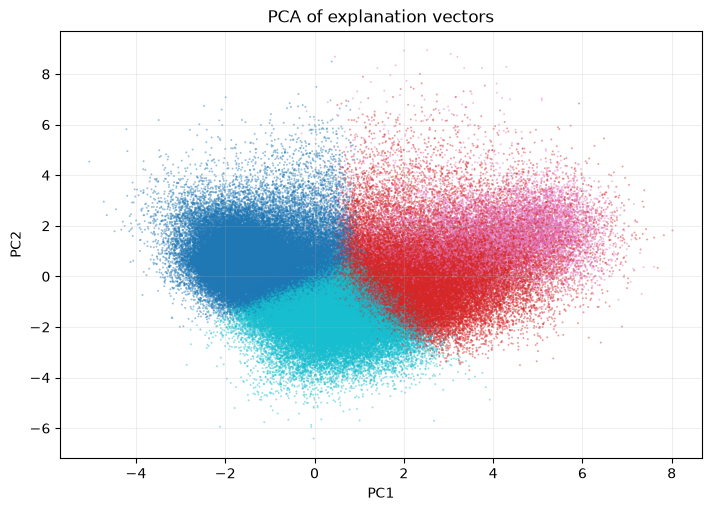

Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/shap_explanation_embedding_pca.csv.gz
Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/shap_explanation_embedding.png


In [5]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
pca_xy = pca.fit_transform(shap_z)
pca_embedding = cluster_cells[[c for c in ['sample_index', 'row', 'col', 'lat', 'lon'] if c in cluster_cells.columns] + ['shap_cluster']].copy()
pca_embedding['pca1'] = pca_xy[:, 0]
pca_embedding['pca2'] = pca_xy[:, 1]
PCA_PATH = EXT_OUTPUT_DIR / 'shap_explanation_embedding_pca.csv.gz'
pca_embedding.to_csv(PCA_PATH, index=False, compression='gzip')
print('PCA explained variance:', np.round(pca.explained_variance_ratio_, 4))

embedding_rng = np.random.default_rng(RANDOM_SEED + 2)
umap_idx = np.sort(embedding_rng.choice(len(cluster_cells), min(UMAP_MAX_ROWS, len(cluster_cells)), replace=False))
umap_embedding = None
try:
    import umap.umap_ as umap_module
    reducer = umap_module.UMAP(
        n_neighbors=30, min_dist=0.1, metric='euclidean',
        random_state=RANDOM_SEED, n_components=2,
    )
    umap_xy = reducer.fit_transform(shap_z[umap_idx])
    umap_embedding = cluster_cells.iloc[umap_idx][[c for c in ['sample_index', 'row', 'col', 'lat', 'lon'] if c in cluster_cells.columns] + ['shap_cluster']].copy()
    umap_embedding['umap1'] = umap_xy[:, 0]
    umap_embedding['umap2'] = umap_xy[:, 1]
    UMAP_PATH = EXT_OUTPUT_DIR / 'shap_explanation_embedding_umap_sample.csv.gz'
    umap_embedding.to_csv(UMAP_PATH, index=False, compression='gzip')
    print('UMAP rows:', f'{len(umap_embedding):,}')
except ImportError:
    UMAP_PATH = None
    print('umap-learn is not installed; PCA output is still available.')

fig, axes = plt.subplots(1, 2 if umap_embedding is not None else 1, figsize=(14 if umap_embedding is not None else 7, 5), constrained_layout=True)
axes = np.atleast_1d(axes)
scatter = axes[0].scatter(pca_embedding['pca1'], pca_embedding['pca2'], c=pca_embedding['shap_cluster'], cmap='tab10', s=2, alpha=0.45, linewidths=0)
axes[0].set_title('PCA of explanation vectors')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
if umap_embedding is not None:
    axes[1].scatter(umap_embedding['umap1'], umap_embedding['umap2'], c=umap_embedding['shap_cluster'], cmap='tab10', s=3, alpha=0.55, linewidths=0)
    axes[1].set_title('UMAP of explanation vectors')
    axes[1].set_xlabel('UMAP1')
    axes[1].set_ylabel('UMAP2')
for ax in axes:
    ax.grid(alpha=0.2)
EMBEDDING_FIG_PATH = EXT_OUTPUT_DIR / 'shap_explanation_embedding.png'
fig.savefig(EMBEDDING_FIG_PATH, dpi=250, bbox_inches='tight')
plt.show()
print('Saved:', PCA_PATH)
print('Saved:', EMBEDDING_FIG_PATH)

## 5. クラスタ世界地図とレジームプロファイル

クラスタ番号自体に意味はない。解釈には、ここで保存するクラスタ別の平均signed SHAP・平均absolute SHAPと、後段の特徴量比較を合わせて使う。

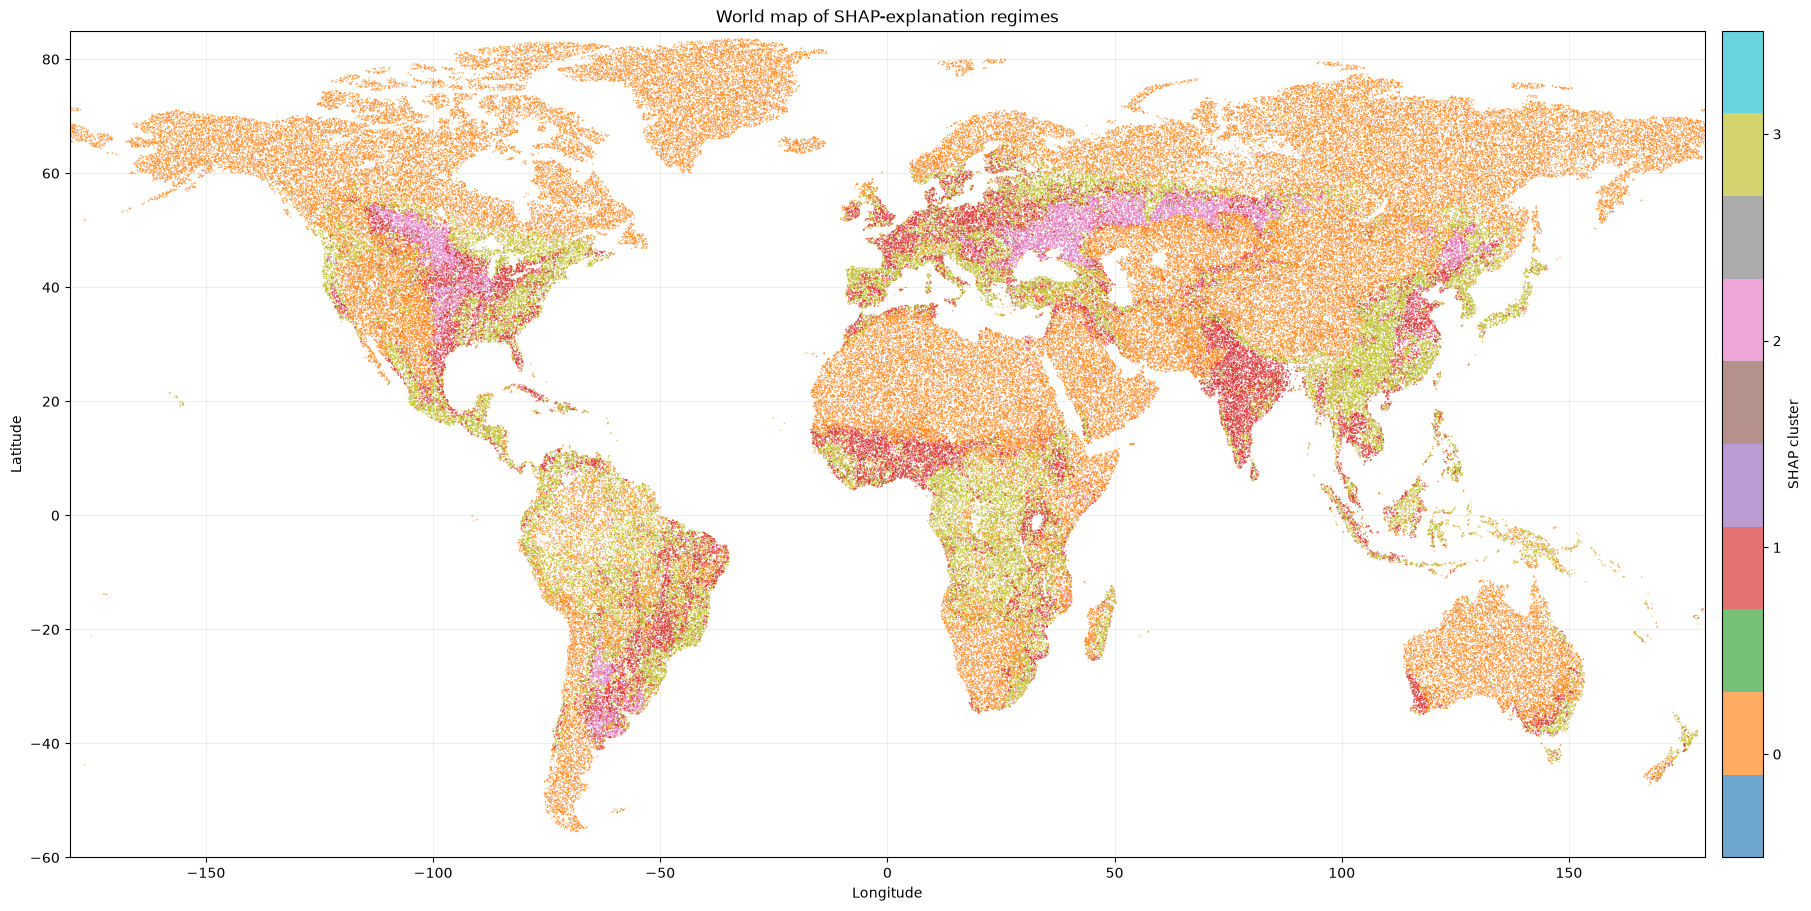

,shap_cluster,feature,mean_abs_shap
0,0,log_city_time_20k_min,0.04479
1,0,wx_50km_rainfed_calorie_top5_raw,0.02388
2,0,rainfed_calorie_top5_raw,0.01809
3,0,soil_group_class,0.01349
4,0,irrigation_calorie_gain_top5_raw,0.01328
5,1,log_city_time_20k_min,0.10603
6,1,wx_50km_rainfed_calorie_top5_raw,0.04011
7,1,rainfed_calorie_top5_raw,0.02975
8,1,soil_group_class,0.02667
9,1,exclusion_class,0.02618


Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/shap_regime_world_map.png


In [6]:
map_df = cluster_cells.dropna(subset=['lat', 'lon']).copy()
if len(map_df) > CLUSTER_MAX_ROWS:
    map_rng = np.random.default_rng(RANDOM_SEED + 3)
    map_df = map_df.iloc[np.sort(map_rng.choice(len(map_df), CLUSTER_MAX_ROWS, replace=False))]

fig, ax = plt.subplots(figsize=(18, 9), constrained_layout=True)
scatter = ax.scatter(
    map_df['lon'], map_df['lat'], c=map_df['shap_cluster'],
    cmap='tab10', vmin=-0.5, vmax=N_CLUSTERS - 0.5,
    s=1.0, alpha=0.65, linewidths=0, rasterized=True,
)
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('World map of SHAP-explanation regimes')
ax.grid(alpha=0.2)
colorbar = fig.colorbar(scatter, ax=ax, ticks=np.arange(N_CLUSTERS), pad=0.01)
colorbar.set_label('SHAP cluster')
MAP_PATH = EXT_OUTPUT_DIR / 'shap_regime_world_map.png'
fig.savefig(MAP_PATH, dpi=300, bbox_inches='tight')
plt.show()

profile_long = cluster_profiles.melt(
    id_vars=['shap_cluster'],
    value_vars=[c for c in cluster_profiles.columns if c.startswith('mean_abs__')],
    var_name='feature', value_name='mean_abs_shap',
)
profile_long['feature'] = profile_long['feature'].str.replace('mean_abs__', '', regex=False)
profile_long = profile_long.sort_values(['shap_cluster', 'mean_abs_shap'], ascending=[True, False])
display(profile_long.groupby('shap_cluster').head(5).reset_index(drop=True).round(5))
print('Saved:', MAP_PATH)

## 6. 元Notebookと同じ分析標本・説明変数を必要時だけ再構成

クラスタリング・PCA・地図は保存済みSHAPだけで実行済み。ここから先のクラスタ別LightGBMと標準Tree SHAP interaction valuesのために、元Notebookと同じサンプル順を再構成する。保存済みOOFの再計算はしない。

In [7]:
HYDE_DIR = ROOT / 'HYDE3.4'
CROPLAND_DIR = HYDE_DIR / 'cropland_npys'
DIST_DIR = ROOT / 'distance_to_cities'
GLOFAS_DIR = ROOT / 'GloFAS' / 'processed_5min'
FEATURE_CACHE = GAEZ_DIR / 'CroplandRegression' / 'features_cache'
WX_CACHE_DIR = GAEZ_DIR / 'CroplandRegression' / 'spatial_wx_comparison'
DERIVED_MASK_DIR = GAEZ_DIR / 'LandMasks' / 'derived_5min'
# TARGET_YEAR is defined in Section 1.
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120000
N_ZERO_SAMPLE = 120000

def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            return np.load(path, mmap_mode='r')
    raise FileNotFoundError('Required feature cache not found: ' + ', '.join(names))

def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)

def positive_raw(values):
    values = np.asarray(values, dtype=np.float32)
    return np.where(np.isfinite(values) & (values > 0), values, 0.0).astype(np.float32)

lat = np.load(CROPLAND_DIR / 'lat.npy')
lon = np.load(CROPLAND_DIR / 'lon.npy')
shape = (len(lat), len(lon))
cropland_cube = np.load(CROPLAND_DIR / 'cropland_fraction_1950_2024.npy', mmap_mode='r')
years = np.load(CROPLAND_DIR / 'years.npy')
year_index = int(np.where(years == TARGET_YEAR)[0][0])
cropland = np.asarray(cropland_cube[year_index], dtype=np.float32).copy()
cropland[~np.isfinite(cropland)] = np.nan

soil_group = np.load(DERIVED_MASK_DIR / 'gaez_v5_wrb_soil_group_5min_mode.npy', mmap_mode='r')
exclusion = np.load(DERIVED_MASK_DIR / 'gaez_v5_exclusion_5min_mode.npy', mmap_mode='r')
# Population is used only for the existing valid-cell mask, not as a predictor.
population = load_cache(
    f'population_density_{TARGET_YEAR}.npy',
    'population_density_2024.npy',
)
elevation = load_cache('elevation_5min.npy')
slope = load_cache('slope_5min.npy')
city_time = np.load(DIST_DIR / 'cities_10_1_12deg_min.npy', mmap_mode='r')
port_time = np.load(DIST_DIR / 'ports_05_1_12deg_min.npy', mmap_mode='r')
glofas = np.load(GLOFAS_DIR / 'p10_discharge_max_5min_2020.npy', mmap_mode='r')
river_distance = np.load(GLOFAS_DIR / 'distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy', mmap_mode='r')
rainfed_calorie = load_cache('rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy', 'rainfed_calorie_top5_checked_36crops.npy')
irrigated_calorie = load_cache('irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy', 'irrigated_calorie_top5_checked_36crops.npy')
WX_CACHE = WX_CACHE_DIR / 'wx_50km_rainfed_calorie_top5_raw.npy'
if not WX_CACHE.exists():
    raise FileNotFoundError('The saved 50-km WX cache is required: ' + str(WX_CACHE))
wx_50km_rainfed_calorie = np.load(WX_CACHE, mmap_mode='r')

for name, raster in {'cropland': cropland, 'soil_group': soil_group, 'exclusion': exclusion, 'elevation': elevation, 'slope': slope, 'city_time': city_time, 'port_time': port_time, 'glofas': glofas, 'river_distance': river_distance, 'rainfed_calorie': rainfed_calorie, 'irrigated_calorie': irrigated_calorie, 'wx_50km_rainfed_calorie': wx_50km_rainfed_calorie}.items():
    if raster.shape != shape:
        raise ValueError(f'Shape mismatch for {name}: {raster.shape} != {shape}')

base_land_mask = np.isfinite(elevation) & np.isfinite(cropland) & np.isfinite(population) & (population >= 0)
valid_exclusion = (exclusion >= 1) & (exclusion <= 6)
permanent_wetland = exclusion == 5
valid_soil = (soil_group >= 1) & (soil_group <= 33)
land_mask = base_land_mask & valid_exclusion & ~permanent_wetland & valid_soil
presence_raster = land_mask & (cropland > PRESENCE_THRESHOLD)
target_prior = float(presence_raster.sum() / land_mask.sum())

rng = np.random.default_rng(RANDOM_SEED)
positive_flat = np.flatnonzero(presence_raster.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence_raster).ravel())
positive_sample = rng.choice(positive_flat, min(N_POS_SAMPLE, len(positive_flat)), replace=False)
zero_sample = rng.choice(zero_flat, min(N_ZERO_SAMPLE, len(zero_flat)), replace=False)
sample_flat = np.concatenate([positive_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, shape)

def take(array):
    return np.asarray(array[rows, cols])

rainfed_sample = take(rainfed_calorie).astype(np.float32)
irrigated_sample = take(irrigated_calorie).astype(np.float32)
calorie_valid = np.isfinite(rainfed_sample) & np.isfinite(irrigated_sample)
irrigation_gain = np.where(calorie_valid, np.maximum(irrigated_sample - rainfed_sample, 0.0), 0.0).astype(np.float32)
sample_frame = pd.DataFrame({
    'row': rows.astype(np.int32), 'col': cols.astype(np.int32),
    'lat': lat[rows].astype(np.float32), 'lon': lon[cols].astype(np.float32),
    'cropland_fraction': take(cropland).astype(np.float32),
    'presence': (take(cropland) > PRESENCE_THRESHOLD).astype(np.uint8),
    'elevation_m': take(elevation).astype(np.float32), 'slope': take(slope).astype(np.float32),
    'exclusion_class': take(exclusion).astype(np.int16), 'soil_group_class': take(soil_group).astype(np.int16),
    'log_city_time_20k_min': safe_log1p(take(city_time)), 'log_port_time_any_min': safe_log1p(take(port_time)),
    'log_glofas_p10_2020': safe_log1p(take(glofas)), 'log_distance_river_gt10_2020': safe_log1p(take(river_distance)),
    'rainfed_calorie_top5_raw': positive_raw(rainfed_sample), 'irrigation_calorie_gain_top5_raw': irrigation_gain,
    'wx_50km_rainfed_calorie_top5_raw': take(wx_50km_rainfed_calorie).astype(np.float32),
})
sample_frame['spatial_block'] = np.floor((sample_frame['lat'] + 90) / 10).astype(int) * 36 + np.floor((sample_frame['lon'] + 180) / 10).astype(int)
sample_frame = sample_frame.replace([np.inf, -np.inf], np.nan).dropna(subset=SOIL_FEATURES + ['cropland_fraction', 'presence']).reset_index(drop=True)
for column in CATEGORICAL_CANDIDATES:
    sample_frame[column] = sample_frame[column].astype('category')
sample_frame['sample_index'] = np.arange(len(sample_frame), dtype=np.int64)

groups = sample_frame['spatial_block'].to_numpy()
splits = list(GroupKFold(n_splits=N_SPLITS).split(sample_frame, sample_frame['presence'], groups=groups))

if 'sample_index' in cluster_cells.columns:
    cluster_lookup = cluster_cells[['sample_index', 'shap_cluster']].drop_duplicates('sample_index')
    sample_frame = sample_frame.merge(cluster_lookup, on='sample_index', how='left', validate='one_to_one')
else:
    cluster_lookup = cluster_cells[['row', 'col', 'shap_cluster']].drop_duplicates(['row', 'col'])
    sample_frame = sample_frame.merge(cluster_lookup, on=['row', 'col'], how='left', validate='one_to_one')

prediction_lookup = oof_predictions[['row', 'col', PREDICTION_COLUMN]].drop_duplicates(['row', 'col'])
sample_frame = sample_frame.merge(prediction_lookup, on=['row', 'col'], how='left', validate='one_to_one')
print('Reconstructed sample rows:', f'{len(sample_frame):,}')
n_cluster_rows = int(sample_frame['shap_cluster'].notna().sum())
n_saved_prediction_rows = int(sample_frame[PREDICTION_COLUMN].notna().sum())
print('Rows with a saved cluster:', f'{n_cluster_rows:,}')
print('Rows with saved OOF prediction:', f'{n_saved_prediction_rows:,}')
print('Population prior used for probability calibration:', target_prior)

Reconstructed sample rows: 240,000
Rows with a saved cluster: 240,000
Rows with saved OOF prediction: 29,596
Population prior used for probability calibration: 0.3660670039858503


## 7. クラスタ別LightGBM推定と保存済みOOFとの比較

各クラスタ内でSpatial GroupKFoldを行う。比較対象の `saved_oof` は元Notebookの最終土壌群モデルの保存済み予測であり、ここでは再学習しない。クラスタの空間ブロック数や学習側のクラス数が不足する場合は、そのクラスタを安全にスキップする。

,shap_cluster,model,status,n,n_blocks,r2,rmse,mae,bias_observed_minus_predicted
0,0,cluster_specific,ok,131848,289,0.62622,0.13537,0.07645,0.01250
1,0,saved_oof,ok,16198,289,0.58195,0.15314,0.09484,0.02042
2,1,cluster_specific,ok,40129,277,0.61953,0.13646,0.07708,0.01205
3,1,saved_oof,ok,4949,277,0.58991,0.15128,0.09282,0.02025
4,2,cluster_specific,ok,12158,268,0.60504,0.14062,0.08099,0.00794
5,2,saved_oof,ok,1471,268,0.58064,0.15449,0.09584,0.02870
6,3,cluster_specific,ok,55865,281,0.62295,0.13550,0.07671,0.01134
7,3,saved_oof,ok,6978,281,0.59346,0.15126,0.09301,0.01925


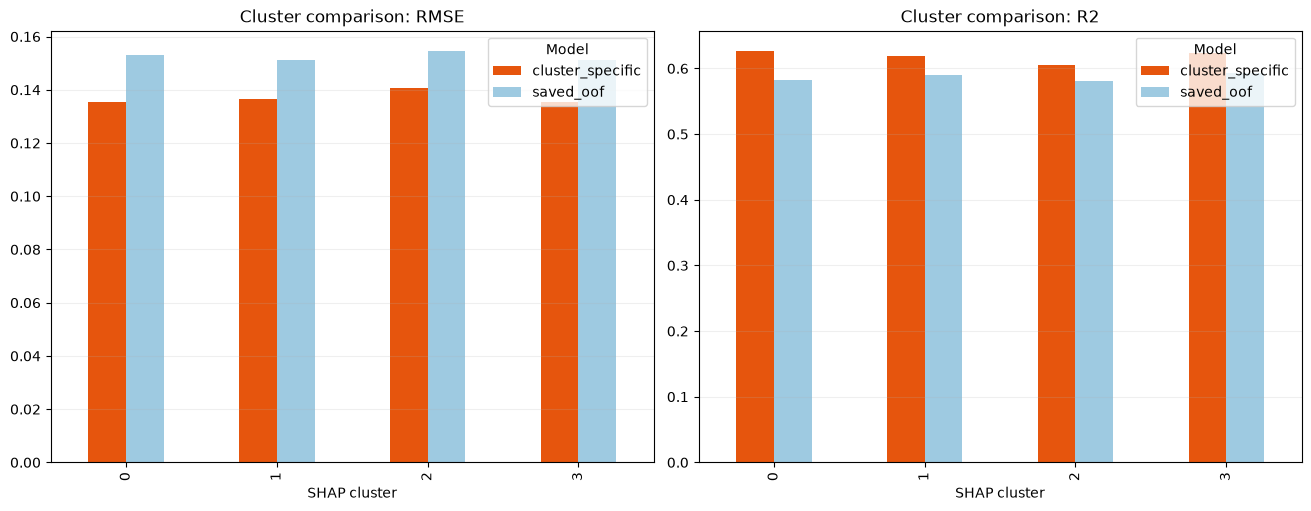

Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/cluster_lgbm_performance.csv
Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/cluster_lgbm_oof_predictions.csv.gz


In [8]:
from lightgbm import LGBMClassifier, LGBMRegressor

def adjust_probability_prior_shift(probability, sample_prior, population_prior, eps=1e-6):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    population_prior = float(np.clip(population_prior, eps, 1 - eps))
    odds = probability / (1 - probability)
    odds *= (population_prior / (1 - population_prior)) / (sample_prior / (1 - sample_prior))
    return odds / (1 + odds)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[valid], y_pred[valid]
    residual = y_true - y_pred
    mean = float(np.mean(y_true))
    ss_tot = float(np.sum((y_true - mean) ** 2))
    return {'n': int(len(y_true)), 'r2': float(1 - np.sum(residual ** 2) / ss_tot) if ss_tot > 0 else np.nan, 'rmse': float(np.sqrt(np.mean(residual ** 2))), 'mae': float(np.mean(np.abs(residual))), 'bias_observed_minus_predicted': float(np.mean(residual))}

def categorical_features_for(features):
    return [f for f in CATEGORICAL_CANDIDATES if f in features]

def fit_two_stage_models(train_df, features, fold_number):
    categorical = categorical_features_for(features)
    classifier = LGBMClassifier(objective='binary', n_estimators=450, learning_rate=0.035, num_leaves=31, min_child_samples=80, subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_SEED + fold_number, n_jobs=4, verbose=-1)
    classifier.fit(train_df[features], train_df['presence'], categorical_feature=categorical)
    positive_train = train_df[train_df['presence'].eq(1)]
    regressor = LGBMRegressor(objective='regression', n_estimators=550, learning_rate=0.03, num_leaves=31, min_child_samples=60, subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_SEED + fold_number, n_jobs=4, verbose=-1)
    regressor.fit(positive_train[features], positive_train['cropland_fraction'], categorical_feature=categorical)
    return classifier, regressor

cluster_metric_rows = []
cluster_prediction_frames = []
if RUN_CLUSTER_LGBM:
    for cluster_id in sorted(sample_frame['shap_cluster'].dropna().astype(int).unique()):
        cluster_data = sample_frame[sample_frame['shap_cluster'].eq(cluster_id)].copy()
        n_blocks = int(cluster_data['spatial_block'].nunique())
        n_splits_cluster = min(N_SPLITS, n_blocks)
        if len(cluster_data) < 500 or n_splits_cluster < 2 or cluster_data['presence'].nunique() < 2:
            cluster_metric_rows.append({'shap_cluster': cluster_id, 'model': 'cluster_specific', 'status': 'skipped: insufficient rows, blocks, or classes', 'n': len(cluster_data), 'n_blocks': n_blocks})
            continue
        cluster_pos = int(cluster_data['presence'].sum())
        if cluster_pos < 100:
            cluster_metric_rows.append({'shap_cluster': cluster_id, 'model': 'cluster_specific', 'status': 'skipped: fewer than 100 positive cells', 'n': len(cluster_data), 'n_blocks': n_blocks})
            continue
        cluster_pred = np.full(len(cluster_data), np.nan, dtype=float)
        cluster_splits = list(GroupKFold(n_splits=n_splits_cluster).split(cluster_data, cluster_data['presence'], groups=cluster_data['spatial_block']))
        for fold_number, (train_idx, test_idx) in enumerate(cluster_splits, start=1):
            train_df = cluster_data.iloc[train_idx]
            test_df = cluster_data.iloc[test_idx]
            if train_df['presence'].nunique() < 2 or int(train_df['presence'].sum()) < 20:
                continue
            classifier, regressor = fit_two_stage_models(train_df, SOIL_FEATURES, fold_number + 100 * (cluster_id + 1))
            raw_probability = classifier.predict_proba(test_df[SOIL_FEATURES])[:, 1]
            calibrated_probability = adjust_probability_prior_shift(raw_probability, float(train_df['presence'].mean()), target_prior)
            conditional_fraction = np.clip(regressor.predict(test_df[SOIL_FEATURES]), 0, 1)
            cluster_pred[test_idx] = calibrated_probability * conditional_fraction
            del classifier, regressor
        valid = np.isfinite(cluster_pred)
        if valid.sum() == 0:
            cluster_metric_rows.append({'shap_cluster': cluster_id, 'model': 'cluster_specific', 'status': 'skipped: no valid fold predictions', 'n': len(cluster_data), 'n_blocks': n_blocks})
            continue
        new_metrics = regression_metrics(cluster_data.loc[valid, 'cropland_fraction'], cluster_pred[valid])
        saved_valid = cluster_data[PREDICTION_COLUMN].notna().to_numpy()
        saved_metrics = regression_metrics(cluster_data.loc[saved_valid, 'cropland_fraction'], cluster_data.loc[saved_valid, PREDICTION_COLUMN]) if saved_valid.any() else {}
        cluster_metric_rows.extend([
            {'shap_cluster': cluster_id, 'model': 'cluster_specific', 'status': 'ok', 'n': int(valid.sum()), 'n_blocks': n_blocks, **new_metrics},
            {'shap_cluster': cluster_id, 'model': 'saved_oof', 'status': 'ok', 'n': int(saved_valid.sum()), 'n_blocks': n_blocks, **saved_metrics},
        ])
        cluster_prediction_frames.append(pd.DataFrame({'sample_index': cluster_data['sample_index'].to_numpy(), 'shap_cluster': cluster_id, 'observed': cluster_data['cropland_fraction'].to_numpy(), 'saved_oof': cluster_data[PREDICTION_COLUMN].to_numpy(), 'cluster_specific_oof': cluster_pred}))

cluster_performance = pd.DataFrame(cluster_metric_rows)
CLUSTER_PERFORMANCE_PATH = EXT_OUTPUT_DIR / 'cluster_lgbm_performance.csv'
CLUSTER_PREDICTIONS_PATH = EXT_OUTPUT_DIR / 'cluster_lgbm_oof_predictions.csv.gz'
cluster_performance.to_csv(CLUSTER_PERFORMANCE_PATH, index=False, encoding='utf-8-sig')
if cluster_prediction_frames:
    cluster_lgbm_predictions = pd.concat(cluster_prediction_frames, ignore_index=True)
else:
    cluster_lgbm_predictions = pd.DataFrame()
cluster_lgbm_predictions.to_csv(CLUSTER_PREDICTIONS_PATH, index=False, compression='gzip')
display(cluster_performance.round(5))

ok_performance = cluster_performance[cluster_performance['status'].eq('ok')].copy()
if not ok_performance.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    for metric, ax in zip(['rmse', 'r2'], axes):
        pivot = ok_performance.pivot(index='shap_cluster', columns='model', values=metric)
        pivot.plot(kind='bar', ax=ax, color={'saved_oof': '#9ECAE1', 'cluster_specific': '#E6550D'})
        ax.set_title(f'Cluster comparison: {metric.upper()}')
        ax.set_xlabel('SHAP cluster')
        ax.grid(axis='y', alpha=0.2)
        ax.legend(title='Model')
    CLUSTER_PERFORMANCE_FIG_PATH = EXT_OUTPUT_DIR / 'cluster_lgbm_performance.png'
    fig.savefig(CLUSTER_PERFORMANCE_FIG_PATH, dpi=250, bbox_inches='tight')
    plt.show()
print('Saved:', CLUSTER_PERFORMANCE_PATH)
print('Saved:', CLUSTER_PREDICTIONS_PATH)

## 8. 標準Tree SHAP interaction values

元Notebookはモデルを保存していないため、ここだけは最終土壌群モデルの5つのSpatial OOF foldを再学習する。保存済みローカルSHAPの行・foldを優先して同じ説明対象を使い、Interaction SHAPのテンソルはfoldごとの圧縮NPZとして保存する。

In [9]:
import shap

INTERACTION_DIR = EXT_OUTPUT_DIR / 'tree_shap_interactions'
INTERACTION_DIR.mkdir(parents=True, exist_ok=True)
INTERACTION_SUMMARY_PATH = EXT_OUTPUT_DIR / 'tree_shap_interaction_summary.csv'

def extract_tree_interactions(explainer, values):
    interaction_values = explainer.shap_interaction_values(values)
    if isinstance(interaction_values, list):
        interaction_values = interaction_values[-1]
    interaction_values = np.asarray(interaction_values)
    if interaction_values.ndim == 4:
        interaction_values = interaction_values[:, :, :, -1]
    if interaction_values.ndim != 3:
        raise ValueError(f'Unexpected interaction shape: {interaction_values.shape}')
    return interaction_values.astype(np.float32, copy=False)

local_key_map = sample_frame[['sample_index', 'row', 'col']].copy()
interaction_stage_specs = {
    'presence_classifier': 'classifier',
    'conditional_fraction_regressor': 'regressor',
}
interaction_paths = []

for stage, model_kind in interaction_stage_specs.items():
    stage_local = local_feature_shap[local_feature_shap['stage'].eq(stage)][['fold', 'row', 'col']].drop_duplicates()
    stage_local = stage_local.merge(local_key_map, on=['row', 'col'], how='inner', validate='many_to_one')
    for fold_number, (train_idx, test_idx) in enumerate(splits, start=1):
        cache_path = INTERACTION_DIR / f'{stage}_fold{fold_number}.npz'
        interaction_paths.append(cache_path)
        if REUSE_INTERACTION_CACHE and cache_path.exists():
            print('Reuse:', cache_path.name)
            continue
        selected = stage_local.loc[stage_local['fold'].eq(fold_number), 'sample_index'].to_numpy(dtype=int)
        selected = selected[np.isin(selected, test_idx)]
        if len(selected) > INTERACTION_MAX_ROWS_PER_FOLD:
            selected_rng = np.random.default_rng(RANDOM_SEED + 5000 + fold_number + (0 if model_kind == 'classifier' else 100))
            selected = np.sort(selected_rng.choice(selected, INTERACTION_MAX_ROWS_PER_FOLD, replace=False))
        if len(selected) == 0:
            fallback_rng = np.random.default_rng(RANDOM_SEED + 6000 + fold_number)
            selected = np.sort(fallback_rng.choice(test_idx, min(INTERACTION_MAX_ROWS_PER_FOLD, len(test_idx)), replace=False))
        train_df = sample_frame.iloc[train_idx]
        selected_df = sample_frame.iloc[selected]
        classifier, regressor = fit_two_stage_models(train_df, SOIL_FEATURES, fold_number)
        model = classifier if model_kind == 'classifier' else regressor
        interaction_values = extract_tree_interactions(shap.TreeExplainer(model), selected_df[SOIL_FEATURES])
        np.savez_compressed(
            cache_path,
            sample_index=selected.astype(np.int64),
            features=np.array(SOIL_FEATURES),
            interaction_values=interaction_values,
            stage=np.array(stage),
            fold=np.array(fold_number),
        )
        print('Saved:', cache_path.name, interaction_values.shape)
        del classifier, regressor, model, interaction_values
        gc.collect()

def weighted_mean(values, weights=None):
    values = np.asarray(values, dtype=float)
    if weights is None:
        return float(np.nanmean(values))
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return float(np.average(values[valid], weights=weights[valid])) if valid.any() else np.nan

pair_summary_rows = []
for cache_path in interaction_paths:
    with np.load(cache_path, allow_pickle=False) as cached:
        selected = cached['sample_index'].astype(int)
        values = cached['interaction_values'].astype(float)
        stage = str(cached['stage'].item())
        fold_number = int(cached['fold'].item())
        features = [str(x) for x in cached['features']]
    weights = None
    for i in range(len(features)):
        for j in range(i + 1, len(features)):
            pair_values = values[:, i, j]
            pair_summary_rows.append({
                'stage': stage, 'fold': fold_number,
                'feature_i': features[i], 'feature_j': features[j],
                'mean_abs_interaction': weighted_mean(np.abs(pair_values), weights),
                'mean_signed_interaction': weighted_mean(pair_values, weights),
                'n': int(len(pair_values)),
            })

interaction_summary_by_fold = pd.DataFrame(pair_summary_rows)
interaction_summary = (
    interaction_summary_by_fold.groupby(['stage', 'feature_i', 'feature_j'], as_index=False)
    .agg(mean_abs_interaction=('mean_abs_interaction', 'mean'), mean_signed_interaction=('mean_signed_interaction', 'mean'), n=('n', 'sum'))
    .sort_values(['stage', 'mean_abs_interaction'], ascending=[True, False])
)
interaction_summary.to_csv(INTERACTION_SUMMARY_PATH, index=False, encoding='utf-8-sig')
print('Saved:', INTERACTION_SUMMARY_PATH)
display(interaction_summary.groupby('stage').head(TOP_INTERACTIONS).round(6))

Saved: presence_classifier_fold1.npz (244, 11, 11)
Saved: presence_classifier_fold2.npz (116, 11, 11)
Saved: presence_classifier_fold3.npz (260, 11, 11)
Saved: presence_classifier_fold4.npz (301, 11, 11)
Saved: presence_classifier_fold5.npz (339, 11, 11)
Saved: conditional_fraction_regressor_fold1.npz (329, 11, 11)
Saved: conditional_fraction_regressor_fold2.npz (112, 11, 11)
Saved: conditional_fraction_regressor_fold3.npz (331, 11, 11)
Saved: conditional_fraction_regressor_fold4.npz (355, 11, 11)
Saved: conditional_fraction_regressor_fold5.npz (461, 11, 11)
Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/tree_shap_interaction_summary.csv


,stage,feature_i,feature_j,mean_abs_interaction,mean_signed_interaction,n
11,conditional_fraction_regressor,exclusion_class,log_city_time_20k_min,0.007121,0.000739,1588
45,conditional_fraction_regressor,slope,log_city_time_20k_min,0.007101,-0.000060,1588
16,conditional_fraction_regressor,exclusion_class,soil_group_class,0.005792,0.002530,1588
43,conditional_fraction_regressor,slope,exclusion_class,0.005660,0.000826,1588
27,conditional_fraction_regressor,log_city_time_20k_min,soil_group_class,0.004777,0.000418,1588
50,conditional_fraction_regressor,slope,soil_group_class,0.004239,0.001297,1588
77,presence_classifier,log_city_time_20k_min,irrigation_calorie_gain_top5_raw,0.124544,-0.060248,1260
83,presence_classifier,log_city_time_20k_min,wx_50km_rainfed_calorie_top5_raw,0.120158,-0.010423,1260
72,presence_classifier,exclusion_class,wx_50km_rainfed_calorie_top5_raw,0.111800,0.001894,1260
66,presence_classifier,exclusion_class,log_city_time_20k_min,0.087779,-0.029725,1260


## 9. 主要interaction dependence plot

各stageで平均absolute interactionが大きい上位ペアを描く。横軸は第1変数、色は第2変数、縦軸はTree SHAP interaction valueである。

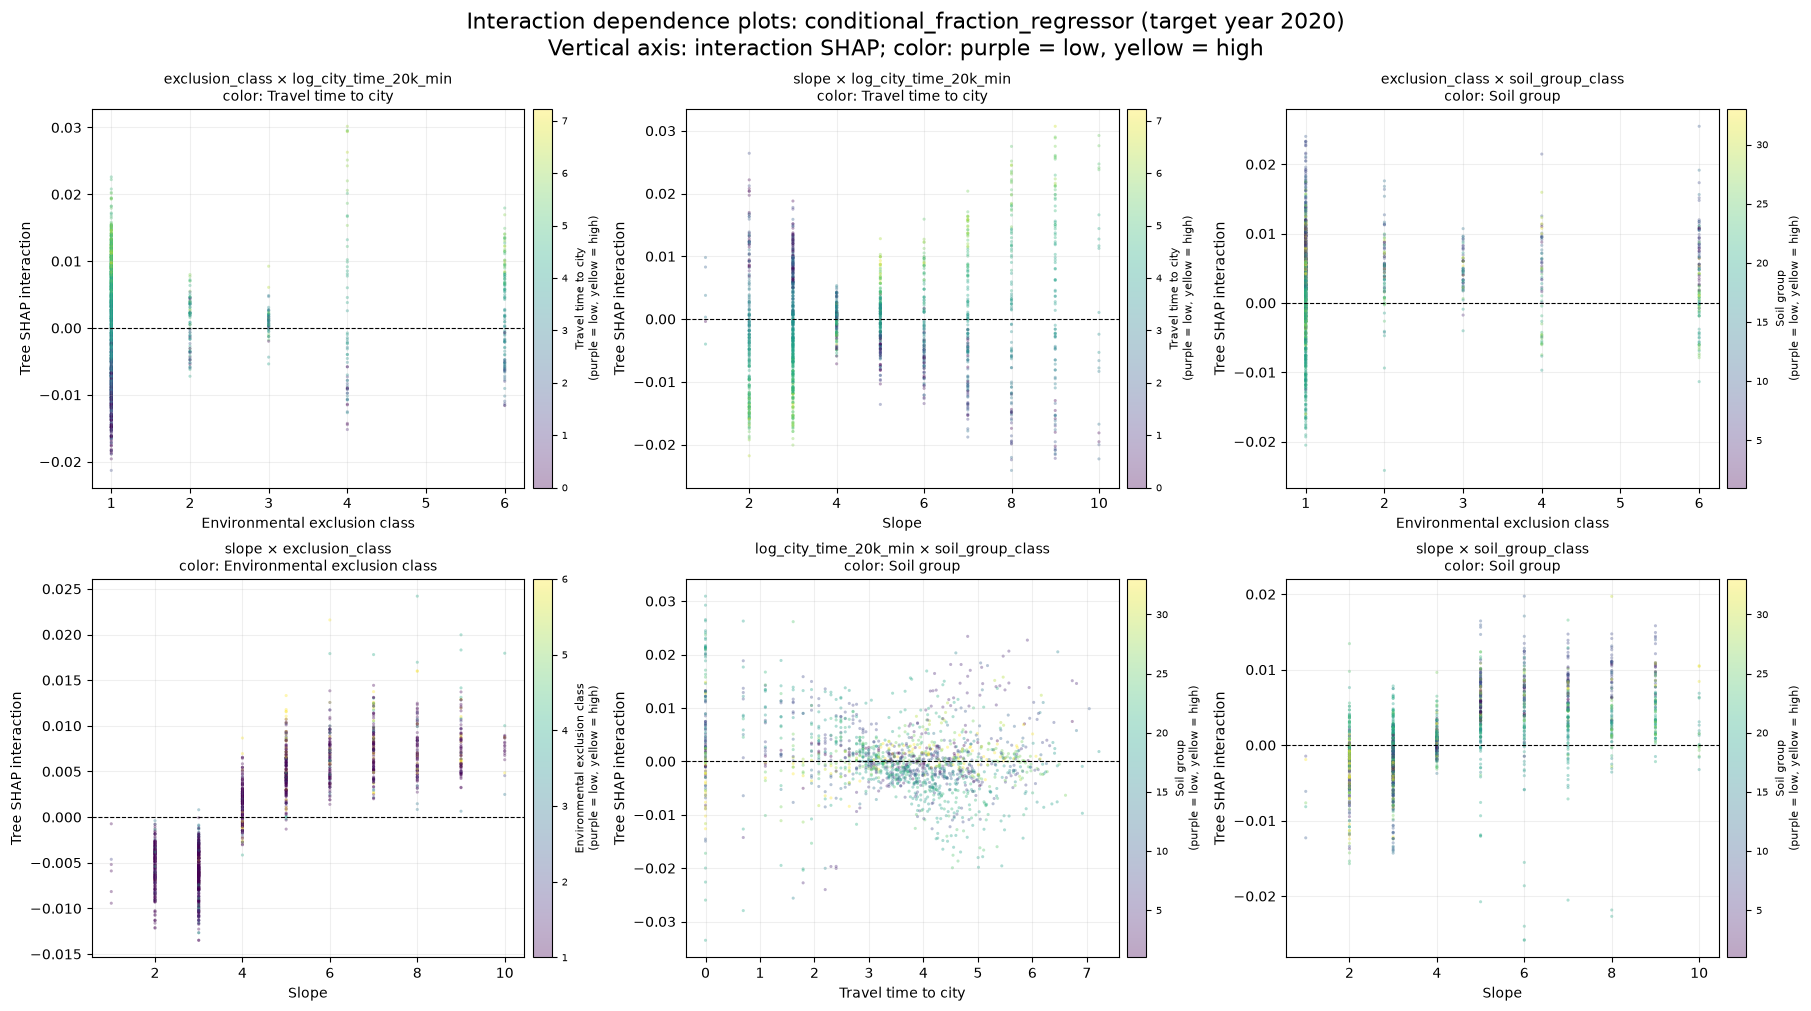

Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/tree_shap_interaction_dependence_conditional_fraction_regressor.png


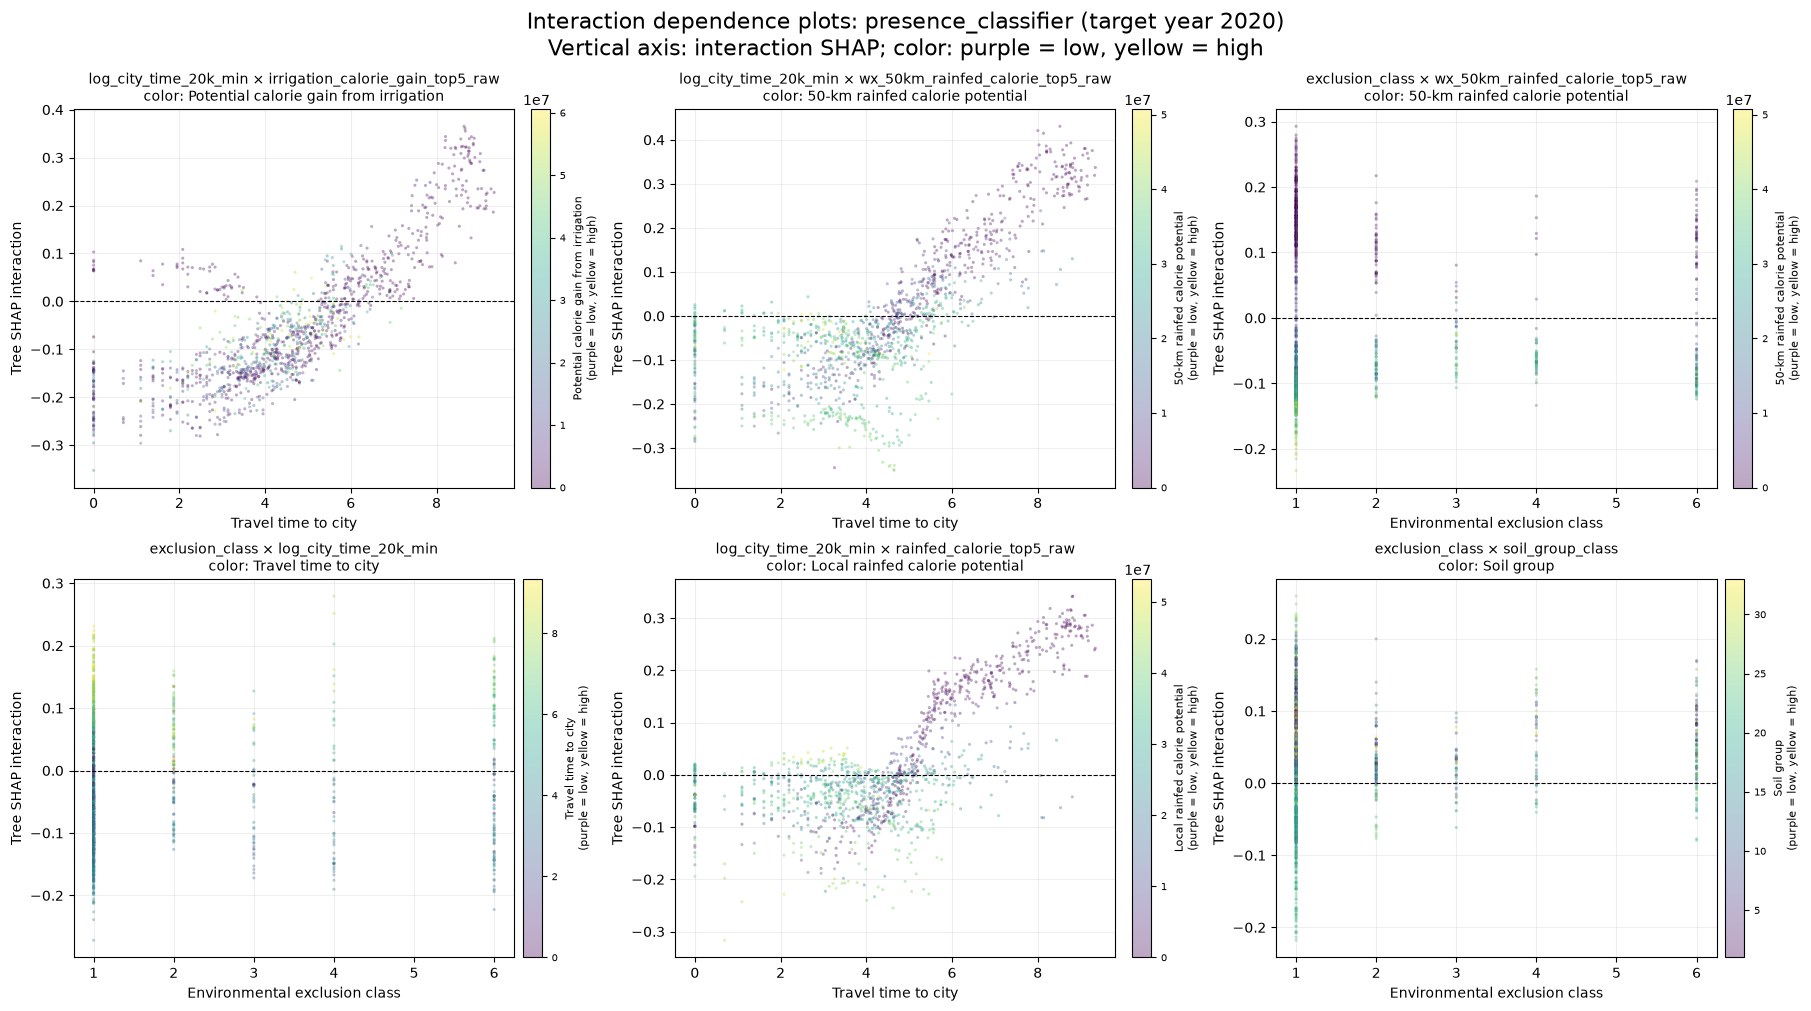

Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/tree_shap_interaction_dependence_presence_classifier.png
Saved: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km/shap_regime_extension_2020/tree_shap_top_pair_values.csv.gz


In [10]:
top_pairs = interaction_summary.groupby('stage', group_keys=False).head(TOP_INTERACTIONS).copy()
pair_value_frames = []

for cache_path in interaction_paths:
    with np.load(cache_path, allow_pickle=False) as cached:
        selected = cached['sample_index'].astype(int)
        values = cached['interaction_values'].astype(float)
        stage = str(cached['stage'].item())
        fold_number = int(cached['fold'].item())
        features = [str(x) for x in cached['features']]
    stage_pairs = top_pairs[top_pairs['stage'].eq(stage)]
    selected_frame = sample_frame.iloc[selected].reset_index(drop=True)
    for pair in stage_pairs.itertuples(index=False):
        i, j = features.index(pair.feature_i), features.index(pair.feature_j)
        pair_value_frames.append(pd.DataFrame({
            'stage': stage, 'fold': fold_number, 'sample_index': selected,
            'feature_i': pair.feature_i, 'feature_j': pair.feature_j,
            'x_value': selected_frame[pair.feature_i].astype(float).to_numpy(),
            'color_value': selected_frame[pair.feature_j].astype(float).to_numpy(),
            'interaction_shap': values[:, i, j],
        }))

interaction_pair_values = pd.concat(pair_value_frames, ignore_index=True) if pair_value_frames else pd.DataFrame()
INTERACTION_VALUES_PATH = EXT_OUTPUT_DIR / 'tree_shap_top_pair_values.csv.gz'
interaction_pair_values.to_csv(INTERACTION_VALUES_PATH, index=False, compression='gzip')

for stage in top_pairs['stage'].unique():
    stage_pairs = top_pairs[top_pairs['stage'].eq(stage)].reset_index(drop=True)
    n_panels = len(stage_pairs)
    if n_panels == 0:
        continue
    n_cols = 3
    n_rows = int(np.ceil(n_panels / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), squeeze=False, constrained_layout=True)
    for panel_index, pair in stage_pairs.iterrows():
        ax = axes.flat[panel_index]
        plot_df = interaction_pair_values[(interaction_pair_values['stage'].eq(stage)) & (interaction_pair_values['feature_i'].eq(pair['feature_i'])) & (interaction_pair_values['feature_j'].eq(pair['feature_j']))]
        plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(
            subset=['x_value', 'color_value', 'interaction_shap']
        )
        scatter = ax.scatter(
            plot_df['x_value'],
            plot_df['interaction_shap'],
            c=plot_df['color_value'],
            cmap='viridis',
            s=5,
            alpha=0.35,
            linewidths=0,
            rasterized=True,
        )
        color_label = FEATURE_LABELS.get(
            pair['feature_j'],
            pair['feature_j'],
        )
        colorbar = fig.colorbar(
            scatter,
            ax=ax,
            fraction=0.046,
            pad=0.02,
        )
        colorbar.set_label(
            f'{color_label}\n(purple = low, yellow = high)',
            fontsize=8,
        )
        colorbar.ax.tick_params(labelsize=7)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel(FEATURE_LABELS.get(pair['feature_i'], pair['feature_i']))
        ax.set_ylabel('Tree SHAP interaction')
        ax.set_title(
            f'{pair.feature_i} × {pair.feature_j}\n'
            f'color: {color_label}',
            fontsize=10,
        )
        ax.grid(alpha=0.2)
    for ax in axes.flat[n_panels:]:
        ax.axis('off')
    fig.suptitle(
        f'Interaction dependence plots: {stage} (target year {TARGET_YEAR})\n'
        'Vertical axis: interaction SHAP; color: purple = low, yellow = high',
        fontsize=16,
    )
    slug = stage.replace(' ', '_').replace('/', '_')
    figure_path = EXT_OUTPUT_DIR / f'tree_shap_interaction_dependence_{slug}.png'
    fig.savefig(figure_path, dpi=250, bbox_inches='tight')
    plt.show()
    print('Saved:', figure_path)

print('Saved:', INTERACTION_VALUES_PATH)